# クロスエントロピー誤差関数
分類問題の損失関数として使用。  
分布の差が大きいほど値が大きくなる。

In [11]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import japanize_matplotlib

In [12]:
def cross_entropy(p, q):
    return -np.sum(p * np.log(q))

1.54529908211736


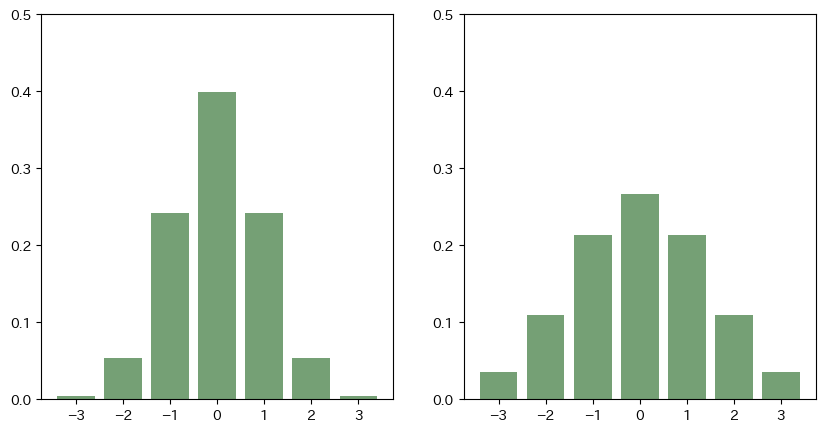

In [13]:
GREEN = "#75a075"
# ガウス分布の離散化
xs = np.linspace(-3, 3, 7)
ys_gauss1 = norm.pdf(xs, loc=0, scale=1)
ys_gauss2 = norm.pdf(xs, loc=0, scale=1.5)
ys_uniform = np.ones_like(xs) / len(xs)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(xs, ys_gauss1, color=GREEN)
axes[1].bar(xs, ys_gauss2, color=GREEN)
for ax in axes.flatten():
    ax.set_ylim(0, 0.5)
print(cross_entropy(ys_gauss1, ys_gauss2))
fig.savefig("cross_entropy1.pdf")

1.9453835065509217


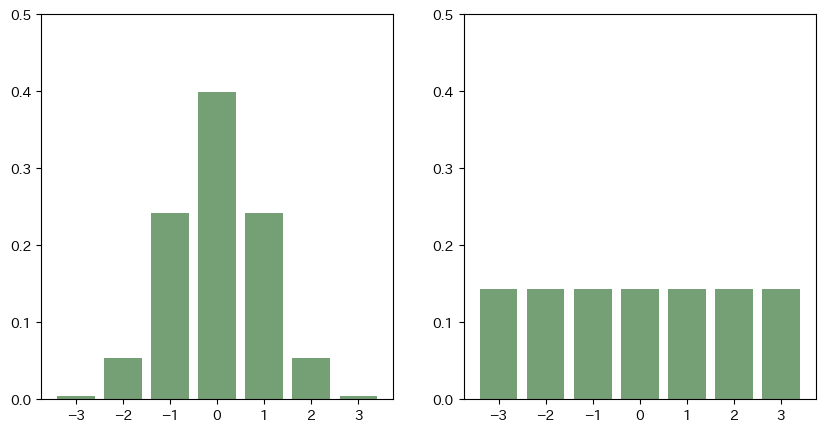

In [14]:
GREEN = "#75a075"
# ガウス分布の離散化
xs = np.linspace(-3, 3, 7)
ys_gauss1 = norm.pdf(xs, loc=0, scale=1)
ys_gauss2 = norm.pdf(xs, loc=0, scale=1.5)
ys_uniform = np.ones_like(xs) / len(xs)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(xs, ys_gauss1, color=GREEN)
axes[1].bar(xs, ys_uniform, color=GREEN)
for ax in axes.flatten():
    ax.set_ylim(0, 0.5)
print(cross_entropy(ys_gauss1, ys_uniform))
fig.savefig("cross_entropy2.pdf")

正解分布は1つの要素のみが1で、残りは0のone-hotベクトルで表される。

0.5108256237659907


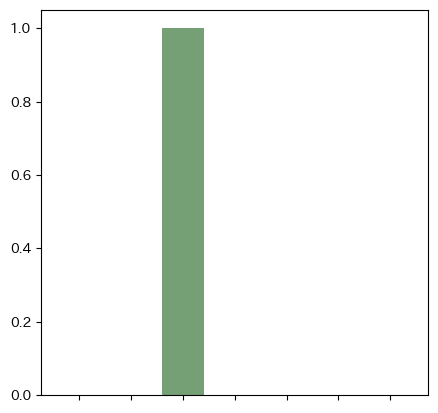

In [15]:
GREEN = "#75a075"
# ガウス分布の離散化
xs = np.linspace(-3, 3, 7)

x_labels = ["吾輩", "僕", "猫", "犬", "ます", "です", "。"] # ボキャブラリー(正解単語の候補)
ys = np.zeros(7)
ys[2] = 1.0 # 猫が正解

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xticklabels([])

ax.bar(x_labels, ys, color=GREEN)
fig.savefig("one_hot.pdf")

# 予測結果の例
pred = np.array([0.1, 0.05, 0.6, 0.05, 0.1, 0.05, 0.05])
print(cross_entropy(ys, pred))


# 2.5.1 クロスエントロピーによる誤差の評価

PyTorchにはクロスエントロピー誤差関数が用意されている。

## 確立分布と確立分布を比べるパターン

In [26]:
import torch
from torch import nn

target = torch.tensor([1.0, 0.0, 0.0])  # 正解
y1 = torch.tensor([0.7, 0.2, 0.1])  # 予測1
y2 = torch.tensor([0.1, 0.2, 0.7])  # 予測2

cross_entropy = nn.CrossEntropyLoss()
print(cross_entropy(y1, target))
print(cross_entropy(y2, target))

tensor(0.7679)
tensor(1.3679)


## 確立分布と正解クラスIDを比べるパターン

In [28]:
import torch
from torch import nn

target = torch.tensor([0])  # 正解(クラスID)
y1 = torch.tensor([0.7, 0.2, 0.1])  # 予測1
y2 = torch.tensor([0.1, 0.2, 0.7])  # 予測2

y1=y1.unsqueeze(0) # 予測1をバッチサイズ1のテンソルに変換
y2=y2.unsqueeze(0) # 予測2をバッチサイズ1のテンソルに変換

cross_entropy = nn.CrossEntropyLoss()
print(cross_entropy(y1, target))
print(cross_entropy(y2, target))

tensor(0.7679)
tensor(1.3679)


In [43]:
target = torch.tensor([[0, 1, 2]])  # 正解(クラスID)
y3 = torch.tensor([[0.7, 0.2, 0.1], [0.3, 0.1, 0.6], [0.1, 0.1, 0.8]])

y3=y3.unsqueeze(0) # 予測値をバッチサイズ1のテンソルに変換
print(y3)
print(y3.shape)

cross_entropy = nn.CrossEntropyLoss()
print(cross_entropy(y3, target))

cross_entropy = nn.CrossEntropyLoss(reduction="none")
print(cross_entropy(y3, target))

tensor([[[0.7000, 0.2000, 0.1000],
         [0.3000, 0.1000, 0.6000],
         [0.1000, 0.1000, 0.8000]]])
torch.Size([1, 3, 3])
tensor(0.9232)
tensor([[0.7971, 1.1331, 0.8395]])
